# Explorador interactivo de radios — Filtración de Vietoris–Rips

**Servicios de salud general en Iztapalapa, CDMX (563 establecimientos).**

Mueve el radio $r$ y observa en vivo cómo evoluciona el complejo simplicial:

- **Bolas** de radio $r/2$ alrededor de cada establecimiento (cobertura). Dos bolas se tocan justo cuando hay una arista ($d \le r$).
- **Aristas** del complejo de Vietoris–Rips: unen pares a distancia $\le r$.
- **Componentes conexas $H_0$**: los “grupos” separados; al crecer $r$ se fusionan (baja $H_0$).
- **Ciclos del grafo**: rango de ciclos del 1-esqueleto. *Es una cota superior de los huecos reales $H_1$* — en el VR completo los triángulos rellenan casi todos. Los huecos reales se aprecian como **espacios naranjas vacíos** en la cobertura y se cuantifican con el diagrama de persistencia.

> La lógica vive en `scripts/interactivo_radios.py` (probada). Aquí la cargamos y la reutilizamos.
> **Kernel:** selecciona el intérprete del `venv` del proyecto.

In [1]:
%matplotlib inline
import importlib.util

spec = importlib.util.spec_from_file_location('intr', 'scripts/interactivo_radios.py')
intr = importlib.util.module_from_spec(spec)
spec.loader.exec_module(intr)

# Carga y precómputo (una sola vez)
xy, es_pub, izt = intr.cargar_datos()
dist_ord, pi, pj = intr.precomputar_pares(xy)
print(f'{len(xy)} establecimientos | {int(es_pub.sum())} públicos')

563 establecimientos | 71 públicos


## 1. Vista estática: la filtración a cuatro radios

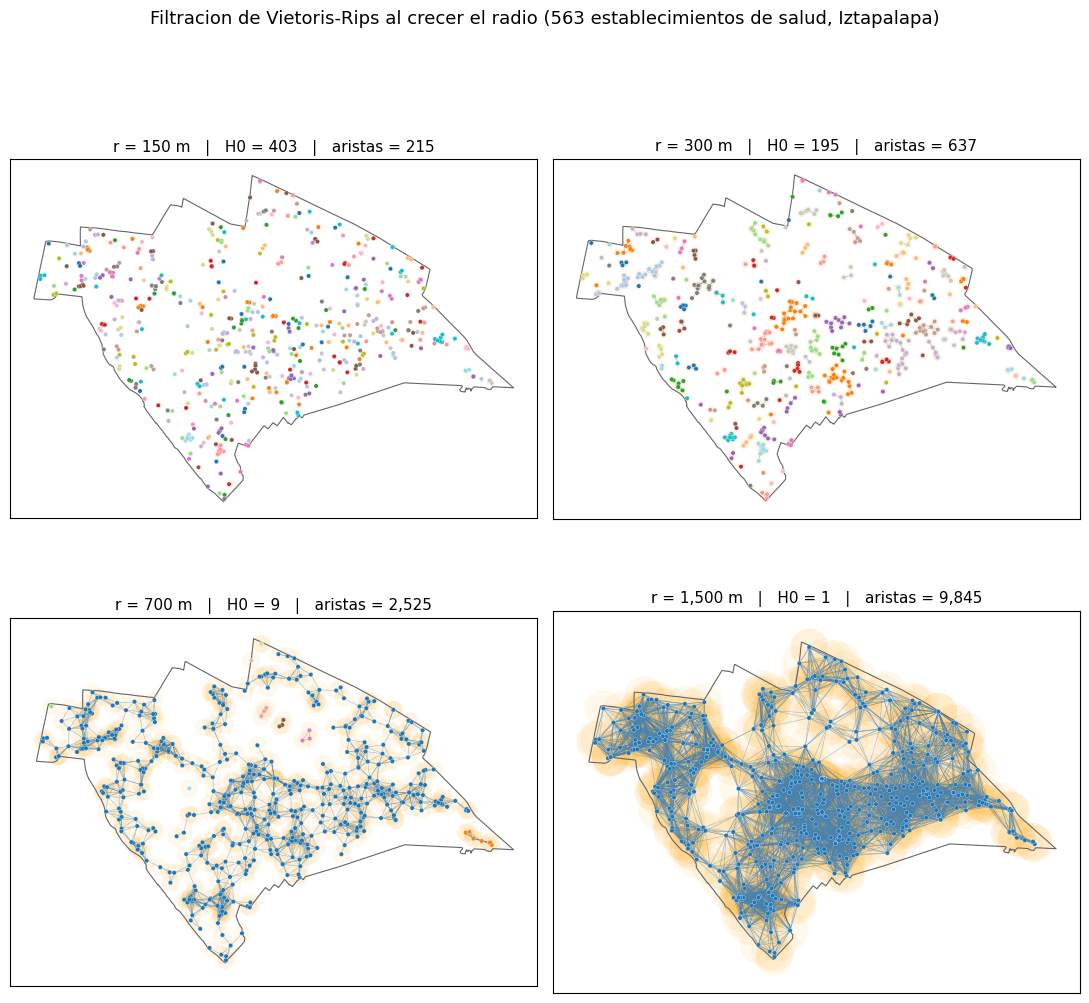

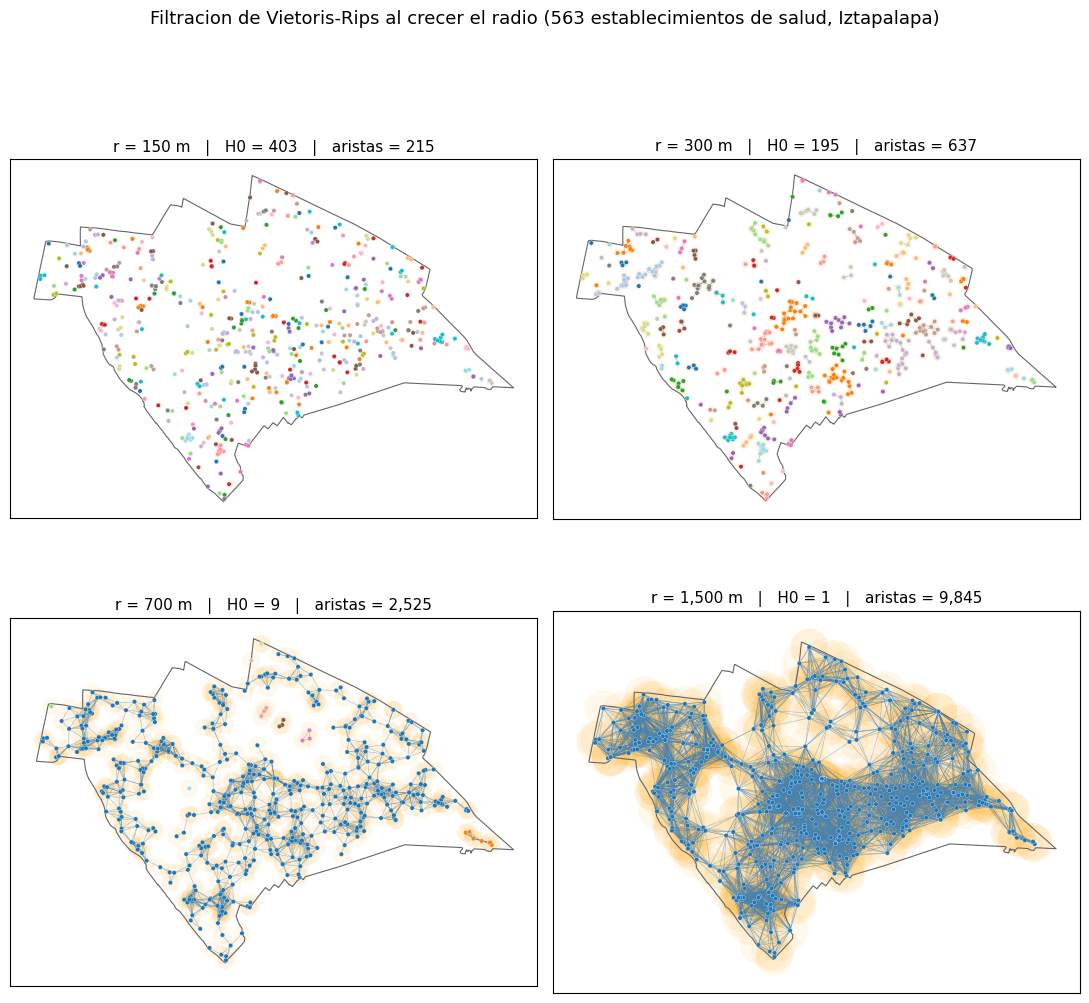

In [2]:
fig = intr.grid_estatico(xy, es_pub, izt, dist_ord, pi, pj,
                         radios=(150, 300, 700, 1500))
fig

## 2. Tabla: métricas topológicas vs. radio

In [3]:
import pandas as pd

filas = []
for r in [100, 161, 300, 500, 700, 1000, 1500, 2000]:
    segs, ncomp, ciclos, labels, k = intr.estado_en_radio(xy, dist_ord, pi, pj, r)
    filas.append({'radio_m': r, 'aristas': k, 'componentes_H0': ncomp,
                  'ciclos_grafo': ciclos})
pd.DataFrame(filas)

,radio_m,aristas,componentes_H0,ciclos_grafo
0,100,111,469,17
1,161,243,384,64
2,300,637,195,269
3,500,1433,47,917
4,700,2525,9,1971
5,1000,4641,1,4079
6,1500,9845,1,9283
7,2000,15953,1,15391


## 3. Interactivo inline (recomendado)

Arrastra el **slider `radio r`** y activa/desactiva *bolas* y *aristas*. Se redibuja en cada cambio.

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Circle

def ver(r=300, bolas=True, aristas=True):
    segs, ncomp, ciclos, labels, k = intr.estado_en_radio(xy, dist_ord, pi, pj, r)
    fig, ax = plt.subplots(figsize=(8, 8))
    izt.boundary.plot(ax=ax, color='0.4', linewidth=0.8, zorder=1)
    if bolas:
        ax.add_collection(PatchCollection(
            [Circle((x, y), r / 2.0) for x, y in xy],
            facecolor='orange', alpha=0.07, edgecolor='orange',
            linewidths=0.15, zorder=0))
    if aristas and k > 0:
        ax.add_collection(LineCollection(
            segs, colors='steelblue', linewidths=0.5, alpha=0.5, zorder=2))
    ax.scatter(xy[:, 0], xy[:, 1], c=labels % 20, cmap='tab20', s=12,
               edgecolors='white', linewidths=0.2, zorder=4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'r = {r:,} m   |   H0 = {ncomp}   |   '
                 f'aristas = {k:,}   |   ciclos grafo = {ciclos}')
    plt.show()

interact(
    ver,
    r=widgets.IntSlider(min=0, max=2500, step=25, value=300,
                        description='radio r', continuous_update=False),
    bolas=True, aristas=True,
);

interactive(children=(IntSlider(value=300, continuous_update=False, description='radio r', max=2500, step=25),…

## 4. Alternativa: ventana interactiva (slider arrastrable)

Si prefieres una ventana con slider arrastrable continuo (estilo pizarrón), ejecuta
la celda siguiente, **o** desde una terminal: `python scripts/interactivo_radios.py`

In [5]:
# %matplotlib tk
# import matplotlib.pyplot as plt
# fig_i, update, s_r, chk = intr.construir_figura(xy, es_pub, izt, dist_ord, pi, pj, r0=300)
# plt.show()